# Model building framework
This notebook is to explore on how to buil the model properly and making it in such way so that cross-validation does work for every encoding strategy.

**However**, special attention must be given to Target encoding where the encoding is dependent on the target variable $y$.

## Plan and framework

### Components

- Encoding methods: Ordinal, Frequency, One-hot and Target encoding

- Data cleaning / preprocessing: handling ?, dropping unused columns, resetting indices, keeping numerical columns unchanged. maybe keep categorical columns also unchanged as encoding is done within the folds

- the k-fold split from the library. train test split is done before the training (outside the loop). 

- model training and usage: Logistic Regression, (optionally) linear SVM / linear regression classifier

- model evaluation: accuracy, precision, recall

- result comparison: compare metrics across encoding strategies (use figures or such)

Loading all relevent methods/libaries

In [40]:
# Enable autoreloading of imported modules
%load_ext autoreload
%autoreload 2

import numpy as np
import matplotlib.pyplot as plt
import sys
import os
import pandas as pd
from courselib.utils.splits import train_test_split
from courselib.utils.splits import k_fold_split
from projectlib.encoding import drop_rows

from courselib.utils.metrics import accuracy

from courselib.models.glm import LogisticRegression
from courselib.models.svm import LinearSVM

from courselib.optimizers import GDOptimizer

from projectlib.encoding import Target_Encoder


# Add the repo root (two levels up from this notebook) to sys.path
sys.path.insert(0, os.path.abspath("../../"))

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


Load data in right format (rows with `?` get dropped)

In [41]:
file_name = "adult.data"
column_names = column_names = [
    "age",
    "workclass",
    "fnlwgt",
    "education",
    "education-num",
    "marital-status",
    "occupation",
    "relationship",
    "race",
    "sex",
    "capital-gain",
    "capital-loss",
    "hours-per-week",
    "native-country",
    "Class"
]
df = pd.read_csv(file_name, names= column_names,skipinitialspace=True)

target_variable_map = {
    "<=50K": 0,
    ">50K": 1,
}

columns_to_be_dropped = [
    "fnlwgt",
]

df= df.drop(columns=columns_to_be_dropped)
df = drop_rows(df,["?"])

df["Class"] = df["Class"].map(target_variable_map)

2399 out of 32561 were deleted, ie.92.63229016307852% still remain 


Some trash helping methods

In [42]:
def k_fold_split_dataframe(df,k):
    perm_ind = np.random.permutation(np.arange(df.shape[0]))
    return [df.iloc[fold_ind] for fold_ind in np.array_split(perm_ind,k)]
    
def data_to_numpy_transfomer(df,class_column_name='Class'):
    X, Y, X_train, Y_train, X_test, Y_test =  train_test_split(df,training_data_fraction=1,class_column_name=class_column_name,return_numpy=True, shuffle= False)
    return X, Y

Define all relevant Parameters

In [49]:
k = 3

optimizer = GDOptimizer(learning_rate=0.01)

target_encoding_cols = [
    "workclass",
    "education",
    "marital-status",
    "occupation",
    "relationship",
    "race",
    "sex",
    "native-country",
]

penalty_funcitons = ["ridge", "lasso"]

lam = [0.0,0.001,0.005,0.01,0.02,0.05,0.1,0.2,0.5,0.7,1.]



Starting with the framework using regularization.ipynb as blueprint.

In [50]:
from courselib.utils.metrics import binary_accuracy
from courselib.utils.normalization import standardize

df_cv = k_fold_split_dataframe(df,k=k)

acc_by_fold = {penalty: [] for penalty in penalty_funcitons}
prec_by_fold = []
rec_by_fold = []

for i in range(len(df_cv)):
    
    df_train = pd.concat(df_cv[:i] + df_cv[i+1:])
    df_test = df_cv[i]
    
    df_train = Target_Encoder(df_train,column_to_be_encoded=target_encoding_cols,target_column_name="Class", delete_old_column = True, drop_unknown_data_rows = ["?"])
    df_test = Target_Encoder(df_test,column_to_be_encoded=target_encoding_cols,target_column_name="Class", delete_old_column = True, drop_unknown_data_rows = ["?"])
    
    x_train, y_train = data_to_numpy_transfomer(df_train,class_column_name='Class')
    x_test, y_test = data_to_numpy_transfomer(df_test,class_column_name='Class')
    
    x_train = standardize(x_train)
    x_test = standardize(x_test)
    
    w = np.zeros(x_train.shape[1])
    b = 0
    
    for penalty in penalty_funcitons:
        
        acc_by_fold[penalty].append([])
        
        for l in lam:
            model = LogisticRegression(w, b, optimizer, penalty=penalty, lam=l)
            model.fit(x_train,y_train, num_epochs = 500, batch_size=len(x_train))
            acc_by_fold[penalty][-1].append(binary_accuracy(model.decision_function(x_test),y_test, class_labels=[1,0]))

Best lambda value for ridge penalty (CV estimate): 0.2
Best lambda value for lasso penalty (CV estimate): 0.02


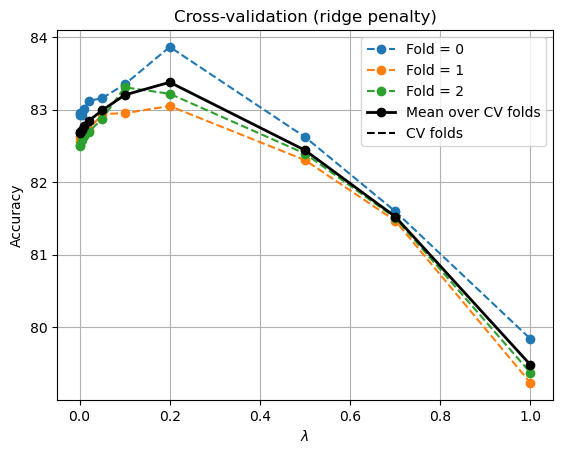

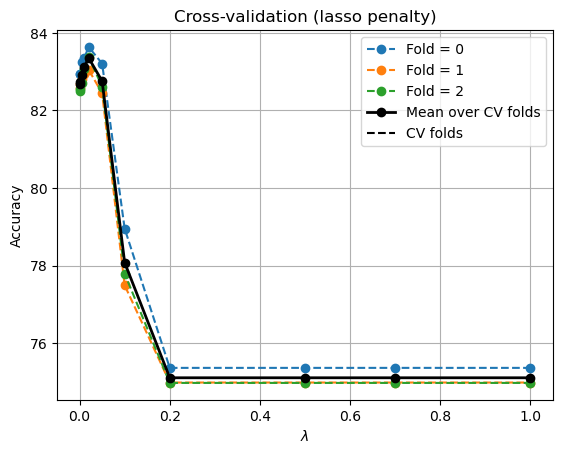

In [51]:
for penalty in penalty_funcitons:
    
    plt.figure()
    
    for i in range(len(acc_by_fold[penalty])):
        plt.plot(lam,acc_by_fold[penalty][i],ls='--', marker='o', label=f"Fold = {i}")
    
    mean_cv_acc = np.mean(np.array(acc_by_fold[penalty]),axis=0)
    plt.plot(lam,mean_cv_acc, color='k', linewidth=2, marker='o', label='Mean over CV folds')
    plt.plot([],[],ls='--',color='k', label='CV folds')
    
    plt.xlabel(r'$\lambda$')
    plt.ylabel('Accuracy')
    plt.title(f'Cross-validation ({penalty} penalty)')
    plt.grid()
    plt.legend()
    
    best_l = lam[np.argmax(mean_cv_acc)]
    print(f"Best lambda value for {penalty} penalty (CV estimate): {best_l}")